<a href="https://colab.research.google.com/github/JoseAlberto88/Hugging-Face-Text-Classification/blob/main/huggingface_text_classification_tutorial_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning Hugging Face Text Classification Tutorial

* Resources notebook: https://www.learnhuggingface.com/notebooks/hugging_face_text_classification_tutorial
* Setup steps: https://www.learnhuggingface.com/extras/setup

**Note** A GPU is needed on Google Colab, go to Runtime -> Change runtime -> Hardware accelerator -> GPU.

### Import necessary libraries

In [1]:
import transformers

In [2]:
# Install dependencies (this is mostly for Google Colab)
try:
  import datasets, evaluate, accelerate
  import gradio as gr
except ModuleNotFoundError:
  !pip install -U datasets evaluate accelerate gradio
  import datasets, evaluate, accelerate
  import gradio as gr

import random

import numpy as np
import pandas as pd

import torch
import transformers

print(f"Using transformers version: {transformers.__version__}")
print(f"Using torch version: {torch.__version__}" )
print(f"Using datasets version: {datasets.__version__}")


Using transformers version: 5.16.1
Using torch version: 2.11.0+cu128
Using datasets version: 5.0.1


## 3. Getting a dataset

Building food not food text classification model: need food not food text dataset.

In [3]:
from datasets import load_dataset

dataset = load_dataset(path="mrdbourke/learn_hf_food_not_food_image_captions")
dataset

README.md:   0%|          | 0.00/1.32k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 11.9kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/250 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 250
    })
})

In [4]:
# What features are there ?

dataset.column_names

{'train': ['text', 'label']}

In [5]:
dataset["train"]

Dataset({
    features: ['text', 'label'],
    num_rows: 250
})

In [6]:
dataset["train"][0]

{'text': 'Creamy cauliflower curry with garlic naan, featuring tender cauliflower in a rich sauce with cream and spices, served with garlic naan bread.',
 'label': 'food'}

### Import random samples


In [7]:
import random

random_indexs = random.sample(range(len(dataset["train"])), 5)

random_samples = dataset["train"][random_indexs]

print(f"[INFO] Random samples from dataset:\n")
for text, label in zip(random_samples["text"], random_samples["label"]):
  print(f"Text: {text} | Label: {label}")

[INFO] Random samples from dataset:

Text: A boy giving his dog a bath in the backyard | Label: not_food
Text: A slice of pizza with a spicy kick, featuring jalapeno peppers | Label: food
Text: Pizza with a gluten-free crust, suitable for those with dietary restrictions | Label: food
Text: Round wooden dining table with chairs gathered around | Label: not_food
Text: Reading a book on the couch, a woman has a cat curled up beside her | Label: not_food


In [8]:
# Get unique label values
dataset["train"].unique("label")

['food', 'not_food']

In [9]:
# Check the count of each label
from collections import Counter

Counter(dataset["train"]["label"])

Counter({'food': 125, 'not_food': 125})

In [10]:
# Turn our dataset into a DataFrame and get a random sample
food_not_food_df = pd.DataFrame(dataset["train"])
food_not_food_df.sample(7)

,text,label
172,"Spicy prawn curry with fresh mint garnish, fea...",food
24,Set of headphones placed on a desk,not_food
188,A basket of fresh strawberries with a sprinkle...,food
213,Chandelier casting light in a dining room,not_food
190,"Asparagus in a bowl, sprinkled with Parmesan c...",food
163,Set of spatulas kept in a holder,not_food
161,Set of measuring cups nested in a drawer,not_food


In [11]:
food_not_food_df["label"].value_counts()

,count
label,
food,125
not_food,125


## 4. Preparing data for text classification

We want to:

1. Tokenize our text -> turn our text into numbers (this goes for labels as well).
2. Create a train/test split -> want to train our model on the training split and want to evaluate our model on the test split.

In [12]:
# Create a mapping for labels to numeric value

id2label = {0: "not_food", 1: "food"}
label2id = {"not_food" : 0, "food" : 1}

print(id2label)
print(label2id)

{0: 'not_food', 1: 'food'}
{'not_food': 0, 'food': 1}


In [13]:
# Create mappings programmatically from dataset
id2label = {idx : label for idx, label in enumerate(dataset["train"].unique("label")[::-1])}
id2label

{0: 'not_food', 1: 'food'}

In [14]:
label2id = {label : idx for idx, label in enumerate(dataset["train"].unique("label")[::-1])}
label2id

{'not_food': 0, 'food': 1}

In [15]:
# turn labels into 0 or 1

def map_labels_to_number(example):
  example["label"] = label2id[example["label"]]
  return example

example_sample = {"text" : "This is a sentence about my favprite food: honey", "label": "food"}

# Test our function
map_labels_to_number(example_sample)

{'text': 'This is a sentence about my favprite food: honey', 'label': 1}

In [16]:
# Map our dataset labels to numbers (the whole thing)
# We do this with dataset.map()  - https://huggingface.co/docs/datasets/process#map
dataset = dataset["train"].map(map_labels_to_number)
dataset[:5]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

{'text': ['Creamy cauliflower curry with garlic naan, featuring tender cauliflower in a rich sauce with cream and spices, served with garlic naan bread.',
  'Set of books stacked on a desk',
  'Watching TV together, a family has their dog stretched out on the floor',
  'Wooden dresser with a mirror reflecting the room',
  'Lawn mower stored in a shed'],
 'label': [1, 0, 0, 0, 0]}

In [17]:
# Shuffle data and look at more 5 random examples
dataset.shuffle()[:5]

{'text': ['Set of cookie cutters collected in a jar',
  'A bowl of pomegranate seeds with a sprinkle of lime zest and a drizzle of agave nectar',
  'Microscope set up on a table',
  'Working from home at her desk, a woman deals with a cat sitting on the keyboard',
  'Birdhouse hanging from a tree'],
 'label': [0, 1, 0, 0, 0]}

### Split the dataset into training and test sets

* Train set = model will learn patters on this dataset
* Validation set (optional) = we can tune our model's hyperparameters on this set
* Test set = model will evaluate patters on this dataset

We can split our dataset using `datasets.Dataset.train_test_split`. https://huggingface.co/docs/datasets/v4.8.4/process#split

In [18]:
# Split our dataset into train/test splits

dataset = dataset.train_test_split(test_size=0.2, seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 50
    })
})

In [19]:
random_idx_train = random.randint(0, len(dataset["train"]))
random_sample_train = dataset["train"][random_idx_train]
random_sample_train

{'text': 'Swimming pool sparkling in a backyard', 'label': 0}

In [20]:
random_idx_test = random.randint(0, len(dataset["test"]))
random_sample_test = dataset["test"][random_idx_test]
random_sample_test

{'text': 'A bowl of sliced tomatoes with a sprinkle of basil and a side of mozzarella cheese',
 'label': 1}

### Tokenizing our text data (turning text into numbers)

The premise of tokenization is to turn words into numbers.

e.g. "I love pizza!" -> [30, 145, 678, 999]

-

The `transformers` library has in-built support for Hugging Face `tokenizers`.
And the class `transformers.AutoTokenizer` helps pair a model to a tokenizer.

-

* To find all models: https://huggingface.co/models
* Model/tokenizer we're going to use: https://huggingface.co/distilbert/distilbert-base-uncased
* Models are aften paired with tokenizers
* Tokenizer = turn text into numbers
* Model = finds patterns in those numbers

In [21]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path="distilbert-base-uncased",
                                          use_fast=True) # use the fast implementation (on by default, note:this requires Rust installed)
tokenizer


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [22]:
# Test out the tokenizer
tokenizer("I love pizza")

{'input_ids': [101, 1045, 2293, 10733, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}

* `input_ids` = our text turned into numbers
* `attention_mask` = whether or not to pay attention to certain tokens (1 = yes pay attention, 0 = no don't pay attention)



In [23]:
# Get the lenght of our tokenizer vocab
length_of_tokenizer_vocab = len(tokenizer.vocab)
print(f"[INFO] Number of items in our tokenizer vocab: {length_of_tokenizer_vocab}")

# Get the maximum sequence lenght the tokenizer can handle
max_tokenizer_input_sequence_length = tokenizer.model_max_length
print(f"[INFO] Max tokenizer input sequence length: {max_tokenizer_input_sequence_length}")

[INFO] Number of items in our tokenizer vocab: 30522
[INFO] Max tokenizer input sequence length: 512


In [24]:
# Does "daniel" occur in the vocab?
tokenizer.vocab["daniel"]

3817

In [25]:
tokenizer.vocab["x"]

1060

In [26]:
tokenizer("akash")

{'input_ids': [101, 9875, 4095, 102], 'token_type_ids': [0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1]}

In [27]:
tokenizer.convert_ids_to_tokens(tokenizer("akash").input_ids)

['[CLS]', 'aka', '##sh', '[SEP]']

In [28]:
# Try to tokenize an emoji
tokenizer.convert_ids_to_tokens(tokenizer("pizza").input_ids)

['[CLS]', 'pizza', '[SEP]']

In [29]:
# Get the first 5 items in the tokenizer vocab
sorted(tokenizer.vocab.items())[:5]

[('!', 999), ('"', 1000), ('#', 1001), ('##!', 29612), ('##"', 29613)]

In [30]:
import random

random.sample(sorted(tokenizer.vocab.items()), k=5)

[('joel', 8963),
 ('bernard', 6795),
 ('neighbourhoods', 27535),
 ('##ᆫ', 30021),
 ('vie', 20098)]

### Making a preprocessing function to tokenize text

what to make it easy to go from sample -> tokenized_sample


In [31]:
def tokenize_text(examples):
  """
  Tokenize given example text and return the tokenized text.
  """
  return tokenizer(examples["text"],
                   padding = True, # pad short sequences to longest sequence length in batch (e.g., if sample lenght=100, sample will be padded to 512 or longest sample in batch)
                   truncation = True # truncate long sequences to the maximum length the model can handle (e.g., if sample length = 1000, model length = 512, sample will be shortened to 512)
                   )

Extra resource: padding and truncation in the docs: https://huggingface.co/docs/transformers/main/en/pad_truncation

In [32]:
example_sample_2 = {"text" : "I love pizza", "label" : 1}

# Test the function
tokenize_text(example_sample_2)

{'input_ids': [101, 1045, 2293, 10733, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}

In [33]:
long_test = "I love pizza " * 1000
len(long_test)

13000

In [34]:
tokenized_long_text = tokenize_text({"text" : long_test, "label" : 1})
tokenized_long_text

{'input_ids': [101, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293, 10733, 1045, 2293,

In [35]:
len(tokenized_long_text["input_ids"])

512

In [36]:
# Map our tokenize text function to the dataset
tokenized_dataset = dataset.map(function=tokenize_text,
                                batched=True, #Set to tokenize across batches of samples at a time rather than one at time
                                batch_size=1000)
tokenized_dataset

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50
    })
})

**Note:** In machine learning, it is often faster to do things in batches rather than one at a time due to leveraging computer hardware parallelization. See more in the map documentation: https://huggingface.co/docs/datasets/v2.1.0/en/process#map

In [37]:
tokenizer.all_special_tokens

['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']

In [38]:
tokenizer.all_special_ids

[100, 102, 0, 101, 103]

In [39]:
# Get two samples from the tokenized datasets
train_tokenized_sample = tokenized_dataset["train"][0]
test_tokenized_sample = tokenized_dataset["test"][0]

for key in train_tokenized_sample.keys():
  print(f"[INFO] Key:")
  print(f"Train sample: {train_tokenized_sample[key]}")
  print(f"Test sample: {test_tokenized_sample[key]}")
  print("\n")

[INFO] Key:
Train sample: Set of headphones placed on a desk
Test sample: A slice of pepperoni pizza with a layer of melted cheese


[INFO] Key:
Train sample: 0
Test sample: 1


[INFO] Key:
Train sample: [101, 2275, 1997, 2132, 19093, 2872, 2006, 1037, 4624, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Test sample: [101, 1037, 14704, 1997, 11565, 10698, 10733, 2007, 1037, 6741, 1997, 12501, 8808, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


[INFO] Key:
Train sample: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Test sample: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


[INFO] Key:
Train sample: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Test sample: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

### Tokenization takeaways

1. Tokenizers = turn data into numbers (e.g. text -> map to number)
2. Many models are out there and have different tokenizers, Hugging Face's Auto (e.g., AutoTokenizer, AutoProcessor, Automodel etc help to match tokenizers to models)
3. Tokenization can happen in parallel using map and batched functions

## Settinng up an evaluation metric

What we want to do: use the evaluation metric to get a numerical idea of how our model is performing.

Some common evaluation metrics for classification:

- Accuracy (how many examples out of 100, did you get correct ?)
- Precision
- Recall
- F1 Score

Evaluation metric is important because some projects may have en evaluation threshold you need to fulfill.

E.g., when I worked on insurance claim classification = require 98% + test accuracy to br commercially viable.

Some places for evaluation metrics:

* Scikit-learn documentation: https://scikit-learn.org/stable/modules/model_evaluation.html
* Hugging Face evaluate: https://huggingface.co/docs/evaluate/types_of_evaluations

In [40]:
import evaluate
import numpy as np
from typing import Tuple

accuracy_metric = evaluate.load("accuracy")

def compute_accuracy(predictions_and_labels: Tuple[np.ndarray, np.ndarray]):
  """
  Compute the accuracy of  model by comparing the predictions and labels.
  """
  predictions, labels = predictions_and_labels

  if len(predictions.shape) >= 2:
    predictions = np.argmax(predictions, axis=1)

  return accuracy_metric.compute(predictions=predictions, references=labels)

In [41]:
# Example predictions and accuracy score
example_preds_all_correct = np.array([0,0,0,0,0,0,0,0,0,0])
example_preds_one_incorrect = np.array([0,0,0,1,0,0,0,0,0,0])
example_labels = np.array([0,0,0,0,0,0,0,0,0,0])

# test the function
print(f"Accuracy when all predictions are correct: {compute_accuracy((example_preds_all_correct, example_labels))}")
print(f"Accuracy when all predictions are incorrect: {compute_accuracy((example_preds_one_incorrect, example_labels))}")

Accuracy when all predictions are correct: {'accuracy': 1.0}
Accuracy when all predictions are incorrect: {'accuracy': 0.9}


## Setting our model to training

- We're going to be using transfer learning.
- Transfer learning is a powerfulk technique, unique to deep learning models that enables us to use the patterns one model has learned on another problem for our own problem.
- See more on transfer learning here: https://en.wikipedia.org/wiki/Transfer_learning

Workflow for training:

1. Create and preprocess data
2. Define the model we'd like to use for our problem: https://huggingface.co/models or see the "task guides" in the HF Transformers docs: https://huggingface.co/tasks/text-generation
3. Define training arguments for training our model `transformers.TrainingArguments`
4. Pass `TrainingArguments` to an instance of `transformers.Trainer`
5. Train the model by calling `Trainer.train()`
6. Save the model (to our local machine or to Hugging Face Hub)
7. Evaluate the trained model by making and inspecting predictions on the test data (and our own custom data of course)
8. Turn teh model into a shareable demo

In [42]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="distilbert/distilbert-base-uncased",
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [43]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


Our model is comprised of the following parts:

1. `embeddings` - embeddings are a form of learned representation of tokens. So if tokens are a direct mapping from token to number, embeddings are a learned vector representation.
2. `transformer` - our model architecture backbone, this has discovered patterns/relationships in the embeddings.
3. `classifier` - we need to custimize this layer to suit our problem.

**Note:** If you get input errors from passing a sample to a model, make sure the sample you pass to your model is formatting in the same way you model was trained on. For example, if your model used a specific tokenizer, make sure to tokenize your text before passing it to the model.

### Count parameters in our model

Weights/parameters = small numeric opportunities for a model to learn patterns in data.

In [44]:
model.parameters()

<generator object Module.parameters at 0x793569eeb5a0>

In [45]:
def count_params(model):
  """
  Count the parameters in a PyTorch model
  """
  trainable_parameters = sum(param.numel() for param in model.parameters() if param.requires_grad)
  total_parameters = sum(param.numel() for param in model.parameters())

  return {"trainable_parameters": trainable_parameters, "total_parameters": total_parameters}

count_params(model)

{'trainable_parameters': 66955010, 'total_parameters': 66955010}

Looks like our model has around 67M parameters and **all** of them are trainable.

Note:
* Generally, the more parameters a model has, the more capacity is has to learn.
* For comparison models such as Llama 3, it has 8 billion parameters.
* If you want the best possible performance, generally more parameters is better.
  * However, with more parameters requires more compute + time.
  * You'll be surprised how well a smaller model can perform with specific data.

### Create a directory for saving models

In [46]:
# Create a model output directory

from pathlib import Path

# Create models dir
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

#Create model save name
model_save_name ="learn_hf_food_not_food_text_classifier-distilbert-base-uncased"

# Create model save path
model_save_dir = Path(models_dir, model_save_name)
model_save_dir


PosixPath('models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased')

### Setting up training arguments (hyperparameters) with TrainingArguments

3. Define training arguments for training our model `transformers.TrainingArguments`
  * These are also known as "hyperparameters" = settings on your model that you can adjust
  * Parameters = weights/patterns in the model that get updated automatically

In [47]:
from transformers import TrainingArguments

print(f"[INFO] Saving model checkpoints: {model_save_dir}")

BATCH_SIZE = 32

# Creating training arguments
training_args = TrainingArguments(
    output_dir=model_save_dir,
    learning_rate=2e-5,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs = 10,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    save_total_limit=3,
    use_cpu = False,
    seed = 42,
    load_best_model_at_end=True,
    logging_strategy = "epoch",
    report_to = "none",
    # hub_token = "Your token her"
    # push_to_hub = True if your want your model to save directly to the Hugging Face after training
    hub_private_repo = False # when uploading to Hugging Face Hub, do you want your repo to be private or public? (default: public)
)

[INFO] Saving model checkpoints: models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased


In [48]:
training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_in_order=True,
dataloader_multiprocessing_context=None,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start

* Docs fro transformers.Trainer: https://huggingface.co/docs/transformers/peft

In [49]:
compute_accuracy

<function __main__.compute_accuracy(predictions_and_labels: Tuple[numpy.ndarray, numpy.ndarray])>

In [50]:
tokenized_dataset["train"]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 200
})

In [51]:
from transformers import Trainer

# Setup Trainer instances
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    processing_class=tokenizer,
    compute_metrics=compute_accuracy
)

trainer

In [52]:
results = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.648363,0.523185,0.940000
2,0.427880,0.298248,0.980000
3,0.227668,0.150641,1.000000
4,0.119689,0.079060,1.000000
5,0.063296,0.044805,1.000000
6,0.041189,0.030503,1.000000
7,0.031049,0.023740,1.000000
8,0.025562,0.020440,1.000000
9,0.023548,0.018871,1.000000
10,0.022661,0.018380,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [53]:
results.metrics

{'train_runtime': 73.3857,
 'train_samples_per_second': 27.253,
 'train_steps_per_second': 0.954,
 'total_flos': 18110777160000.0,
 'train_loss': 0.1630904429725238,
 'epoch': 10.0}

In [54]:
# Inspect training metrics

for key, value in results.metrics.items():
  print(f"{key} : {value}")

train_runtime : 73.3857
train_samples_per_second : 27.253
train_steps_per_second : 0.954
total_flos : 18110777160000.0
train_loss : 0.1630904429725238
epoch : 10.0


### save the model for later us

> **Note:** if you are saving a model to Google Colab, note that it will desappear from your Colab instances when it disconnets.

In [55]:
# Save model
print(f"[INFO] Saving model to {model_save_dir}")
trainer.save_model(output_dir=model_save_dir)

[INFO] Saving model to models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Inspect the model training metrics

In [56]:
# get training history

trainer_history_all = trainer.state.log_history
trainer_history_metrics = trainer_history_all[:-1]
trainer_history_training_time = trainer_history_all[:-1]

# View teh first 3
trainer_history_metrics[:3]

[{'loss': 0.6483634540012905,
  'grad_norm': 3.5875728130340576,
  'learning_rate': 1.8285714285714288e-05,
  'epoch': 1.0,
  'step': 7},
 {'eval_loss': 0.5231845378875732,
  'eval_accuracy': 0.94,
  'eval_runtime': 0.1787,
  'eval_samples_per_second': 279.812,
  'eval_steps_per_second': 11.192,
  'epoch': 1.0,
  'step': 7},
 {'loss': 0.4278795378548758,
  'grad_norm': 3.365543842315674,
  'learning_rate': 1.6285714285714287e-05,
  'epoch': 2.0,
  'step': 14}]

In [57]:
import pprint

# Extract eval and training metrics
trainer_history_training_set = []
trainer_history_eval_sets = []

# Loop through our metrics
for item in trainer_history_metrics:
  item_keys = list(item.keys())
  if any("eval" in item for item in item_keys):
    trainer_history_eval_sets.append(item)
  else:
    trainer_history_training_set.append(item)

# Show the first item from each
print(f"First item in training set:")
pprint.pprint(trainer_history_training_set[2])
print("\n")
print(f"First item in eval set:")
pprint.pprint(trainer_history_eval_sets[2])

First item in training set:
{'epoch': 3.0,
 'grad_norm': 1.559863805770874,
 'learning_rate': 1.4285714285714287e-05,
 'loss': 0.22766760417393275,
 'step': 21}


First item in eval set:
{'epoch': 3.0,
 'eval_accuracy': 1.0,
 'eval_loss': 0.1506410390138626,
 'eval_runtime': 0.0572,
 'eval_samples_per_second': 874.765,
 'eval_steps_per_second': 34.991,
 'step': 21}


### Taking a look at the loss curve

Loss curve = a good visualization of your model's performance over time.

Ideally, loss curves will trend downwards.

See more here: https://developers.google.com/machine-learning/foundational-courses

In [58]:
# Create a pandas DataFrame for the training and evaluation metrics
trainer_history_train_df = pd.DataFrame(trainer_history_training_set)
trainer_history_eval_df = pd.DataFrame(trainer_history_eval_sets)

trainer_history_train_df.head()

,loss,grad_norm,learning_rate,epoch,step
0,0.648363,3.587573,0.000018,1.0,7
1,0.427880,3.365544,0.000016,2.0,14
2,0.227668,1.559864,0.000014,3.0,21
3,0.119689,0.901602,0.000012,4.0,28
4,0.063296,0.540978,0.000010,5.0,35


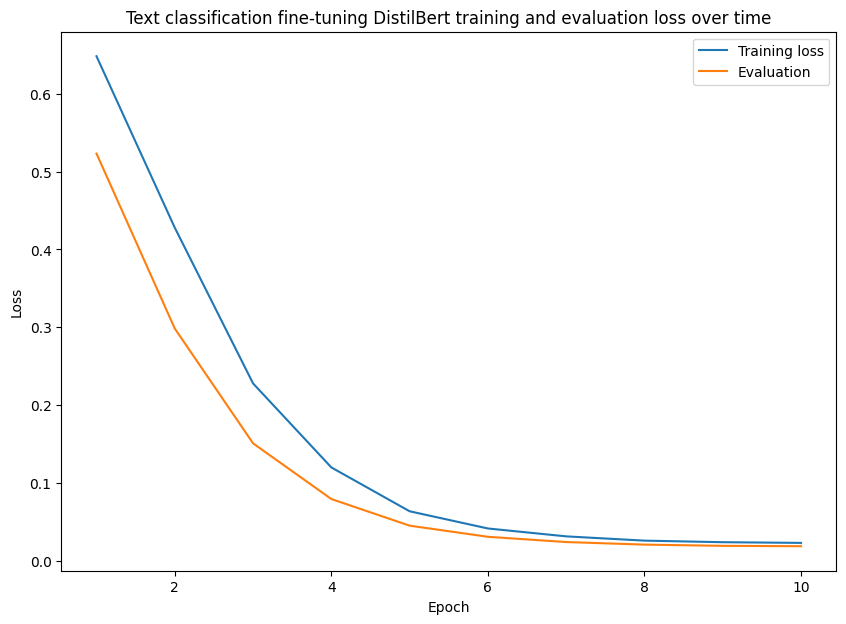

In [59]:
# Plot the loss cure
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.plot(trainer_history_train_df["epoch"], trainer_history_train_df["loss"], label="Training loss")
plt.plot(trainer_history_eval_df["epoch"], trainer_history_eval_df["eval_loss"], label="Evaluation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Text classification fine-tuning DistilBert training and evaluation loss over time")
plt.show()

To learn more about underfinting and overfiting see: https://en.wikipedia.org/wiki/Overfitting

### Pushing our model to the Hugging Fac Hub

Why do this ?

So we can share our model.

Other people can try it out.

We can keep a history of different model versions.

To write to Hugging Face:
- If on Google Colab: setup "token" with "read and write" access
- If on local machine: setup `huggingface-cli`n https://huggingface.co/docs

To save to the Hugging Face Hub, we can use the Trainer.push_to_hub method:
https://huggingface.co/docs/transformers/v5.17.0/en/main_classes/trainer#transformers.Trainer.push_to_hub

In [60]:
# save our model to the Hugging Face Hub
model_upload_url = trainer.push_to_hub(
    commit_message = "Updating food not food text classifier model",
    # hub_token = "Your token here
)
print(f"[INFO] Model successfully uploaded to the Hugging Face Hub with URL: {model_upload_url}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[INFO] Model successfully uploaded to the Hugging Face Hub with URL: https://huggingface.co/JoseA1988/learn_hf_food_not_food_text_classifier-distilbert-base-uncased/commit/3330ec61c9054a9feb371ca936d1f9b46830b877


### Making and evaluating predictions on the test data

> **Note:** Evaluating a model is just as important as training a model.

We can use predictions on the test data using the Trainer.predict method: https://huggingface.co/docs/transformers/v5.17.0/en/main_classes/trainer#transformers.Seq2SeqTrainer.predict

In [61]:
# Perfom preditions on the test data

predictions_all  = trainer.predict(tokenized_dataset["test"])
prediction_values = predictions_all.predictions
prediction_metrics = predictions_all.metrics

print(f"[INFO] Predictions metrics on the test data")
prediction_metrics

[INFO] Predictions metrics on the test data


{'test_loss': 0.01837960258126259,
 'test_accuracy': 1.0,
 'test_runtime': 0.0929,
 'test_samples_per_second': 538.3,
 'test_steps_per_second': 21.532}

In [62]:
predictions_all.predictions[0]

array([-2.0127926,  2.040269 ], dtype=float32)

In [63]:
# Soft max gets all the values to be between 0 and 1 and the total of teh values sum to 1
# This is what's known as a "prediction probability", as in the model is assigning this value to how "likely" the prediction is given the sample

import torch

torch.softmax(torch.tensor(predictions_all.predictions[0]), dim=0)

tensor([0.0171, 0.9829])

**Note:** If you want a good evaluation method, make the predictions on your entire test dataset, then index on the predictions which are wrong but have high prediction probability. For example, get the top 100-1000 and go through all the examples where the model's prediction had high probability but was incorrect -> this often leads to great insights into your data.

**Note:** These values don't suggest how "right" the model is, because a model can have a high prediction probability but still be wrong

### let's get predicted probabilities and evaluate by hand

In [64]:
# predicted logits (raw output of the model) -> prediction probabilities with torch.softmax -> predicted labels

import torch
from sklearn.metrics import accuracy_score

# 1. get prediction probabilities with torch.soft_max
pred_probs = torch.softmax(torch.tensor(prediction_values), dim=1)

# 2. get predicted labels with torch.argmax
pred_labels = torch.argmax(pred_probs, dim=1)

# 3. get the true labels
true_labels = dataset["test"]["label"]

# 4. Compute prediction labels to true labels and get the test accuracy
test_accuracy = accuracy_score(y_true=true_labels, y_pred=pred_labels)

print(f"[INFO] Test accuracy: {test_accuracy}")


[INFO] Test accuracy: 1.0


### Exploring our models prediction probabilities

It's a very good way to evaluate a model by sorting predictions probabilities and seeing where the model when wrong

In [68]:
# Make a DataFrame of test predictions

test_predictions_df = pd.DataFrame({
    "text" : tokenized_dataset["test"]["text"],
    "true_label" : true_labels,
    "pred_labels" : pred_labels,
    "pred_prob" : torch.max(pred_probs, dim=1).values
})

test_predictions_df.head()

,text,true_label,pred_labels,pred_prob
0,A slice of pepperoni pizza with a layer of mel...,1,1,0.982927
1,Red brick fireplace with a mantel serving as a...,0,0,0.968885
2,A bowl of sliced bell peppers with a sprinkle ...,1,1,0.984773
3,Set of mugs hanging on a hook,0,0,0.982666
4,Standing floor lamp providing light next to an...,0,0,0.981732


In [69]:
# Show 10 examples with the low prediction probability
test_predictions_df.sort_values("pred_prob", ascending = True).head(10)

,text,true_label,pred_labels,pred_prob
11,A close-up shot of a cheesy pizza slice being ...,1,1,0.961801
1,Red brick fireplace with a mantel serving as a...,0,0,0.968885
17,"Relaxing on the porch, a couple enjoys the com...",0,0,0.970140
42,"Boxes of apples, pears, pineapple, manadrins a...",1,1,0.970217
39,A close-up of a woman practicing yoga in the l...,0,0,0.974241
14,Two handfuls of bananas in a fruit bowl with g...,1,1,0.975834
22,Two people sitting at a dining room table with...,0,0,0.978598
27,A close-up of a cat lounging on a windowsill w...,0,0,0.978961
12,A boy giving his dog a bath in the backyard,0,0,0.978966
23,Yoga mat rolled up and ready in a corner,0,0,0.979601


## making and expecting predictions on custom text data

**Note:** Whenever you hear the word "inference" it means to use a model to make predictions on data.

Two main ways to perform inference:

1. **Pipeline mmode** - Using `transformers.pipeline` to load our model and perform text classification. See the docs: https://huggingface.co/docs/transformers/pipeline_tutorial
2. **PyTorch mode** - Using a combination of `transformers.AutoTokenizer` and `transformers.AutoModelForSequenceClassification` and passing each our target model name.

Each model supports:

1. Predictions one at a time (fast but can be slower with many many examples)
  * Helpful for say a comment system and comments happen sporadically, to predict whether the comment was "spam" or "not spam".
2. Batches of predictions at a time (faster but up to a point, e.g., say you predict on 32 samples at a time, this may be way faster than one at time but if you go to 128 at a time, you may not see many more speedups)
  * Helpful for when you have a large static database or many examples coming in at one.
  

In [72]:
local_model_path = "models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased"

huggingface_model_path = "JoseA1988/learn_hf_food_not_food_text_classifier-distilbert-base-uncased"

In [73]:
# Setup our device for makimg predictions
# Note: generally the faster the hardware accelerator, the faster the predictions.
# For example if yiou have a dedicated GPU, you should use it over CPU.

def set_device():
  if torch.cuda.is_available():
    device = torch.device("cuda")
  elif torch.backends.mps.is_available() and torch.backneds.mps.is_built():
    device = torch.device("mps")
  else:
    device = torch.device("cpu")
  return device

DEVICE = set_device()
print(f"[INFO] Using device: {DEVICE}")


[INFO] Using device: cuda


### MAking predictions with pipeline mode

See docs : https://huggingface.co/docs/transformers/pipeline_tutorial

In [74]:
import torch
from transformers import pipeline

# Set the batch size.
BATCH_SIZE = 32 # reminder: predictions speed often increases with higher batch size (e.g., 1 -> 32 but can saturate at even higher batch sizes)

# Create a instance of transformers.pipeline
food_not_food_classifier = pipeline(task = "text-classification",
                                    model=local_model_path,
                                    device=DEVICE,
                                    top_k=1,
                                    batch_size=BATCH_SIZE)

food_not_food_classifier

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

TextClassificationPipeline: {'model': 'DistilBertForSequenceClassification', 'dtype': 'float32', 'device': 'cuda', 'input_modalities': 'text'}

In [76]:
test_custom_sentence = "For breakfast I had rice cakes and fish!"
food_not_food_classifier(test_custom_sentence)

[[{'label': 'food', 'score': 0.8939131498336792}]]